# Question 3: Construction of Continuous Futures Series

**Objective:**
1. Download Spot and Futures data for Gold (GC=F).
2. Construct a continuous price series using the rollover method.
3. Perform ADF Unit Root Tests.
4. Test for Cointegration and interpret results.

In [6]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, coint

In [7]:
# ============================================================
# CELL 3 - Download raw price data
# What is downloaded:
#   GOLDBEES.NS  : SBI Gold ETF on NSE - used as Indian Gold
#                  spot price proxy (INR per gram). We multiply
#                  by 10 to get INR per 10g (MCX convention).
#   GC=F         : COMEX Gold front-month futures (USD/troy oz).
#                  We convert to INR/10g using the exchange rate.
#   INR=X        : USD to INR daily exchange rate.
# ============================================================

START = '2014-01-01'
END   = '2024-12-31'

# ── FIX: yfinance >= 0.2.x returns a 2-D DataFrame (MultiIndex columns)
# even for a single ticker. We use .squeeze() to always get a 1-D Series.
def download_series(ticker, start, end):
    raw   = yf.download(ticker, start=start, end=end,
                        auto_adjust=True, progress=False)
    close = raw['Close']
    if isinstance(close, pd.DataFrame):
        close = close.squeeze()   # (N,1) DataFrame -> (N,) Series
    close = close.squeeze()       # belt-and-suspenders: ensure 1-D
    close.name = ticker
    return close

print("Downloading Gold spot ETF (GOLDBEES.NS)...")
gold_etf      = download_series('GOLDBEES.NS', START, END)
gold_spot_raw = gold_etf * 10        # INR/gram -> INR/10g

print("Downloading USD/INR exchange rate (INR=X)...")
usd_inr       = download_series('INR=X', START, END)

print("Downloading COMEX Gold futures (GC=F)...")
gold_fut_usd  = download_series('GC=F', START, END)

# Convert COMEX futures from USD/troy oz  ->  INR/10g
# 1 troy oz = 31.1035 grams  =>  1 troy oz = 3.11035 units of 10g
TROY_OZ_PER_10G = 31.1035 / 10

# Align usd_inr to the futures trading dates before multiplying
usd_inr_aligned = usd_inr.reindex(gold_fut_usd.index).ffill()
gold_fut_inr    = gold_fut_usd * usd_inr_aligned * (1 / TROY_OZ_PER_10G)

# Verify all are genuinely 1-D before proceeding
assert gold_spot_raw.ndim == 1, f"spot is {gold_spot_raw.ndim}-D, expected 1-D"
assert usd_inr.ndim       == 1, f"usd_inr is {usd_inr.ndim}-D, expected 1-D"
assert gold_fut_inr.ndim  == 1, f"futures is {gold_fut_inr.ndim}-D, expected 1-D"

print("\nAll series confirmed 1-D. Shapes:")
print(f"  Spot ETF (INR/10g) : {gold_spot_raw.shape}")
print(f"  USD/INR rate       : {usd_inr.shape}")
print(f"  Futures (INR/10g)  : {gold_fut_inr.shape}")
print("\nSample spot values:")
print(gold_spot_raw.tail(3).to_string())


All series confirmed 1-D. Shapes:
  Spot ETF (INR/10g) : (2708,)
  USD/INR rate       : (2866,)
  Futures (INR/10g)  : (2764,)

Sample spot values:
Date
2024-12-26    640.000000
2024-12-27    642.099991
2024-12-30    640.000000


In [8]:
# ============================================================
# CELL 4 - Merge, clean and build master DataFrame
# After this cell:
#   df           : price levels with columns 'spot' and 'futures'
#   df_diff      : first differences (Delta_S and Delta_F)
#   df_logret    : daily log returns
# ============================================================

# Merge on common trading dates.
# We use pd.concat to safely align two 1-D Series into a 2-column DataFrame.
df_raw = pd.concat([gold_spot_raw.rename('spot'),
                    gold_fut_inr.rename('futures')], axis=1)
df_raw = df_raw.ffill().dropna()

# ---- Build continuous futures via Panama-canal rollover adjustment --------
# Yahoo's GC=F already rolls automatically, but large single-day price jumps
# (> 1.5%) on rollover dates create spurious gaps. We subtract those gaps
# from all prior history so the series is gapless and level-consistent.

futures_pct_chg = df_raw['futures'].pct_change().abs()
roll_dates = futures_pct_chg[futures_pct_chg > 0.015].index
print(f"Detected {len(roll_dates)} roll dates (jumps > 1.5%)")

futures_adj = df_raw['futures'].copy()
for rd in sorted(roll_dates, reverse=True):
    idx = df_raw.index.get_loc(rd)
    if idx == 0:
        continue
    gap = df_raw['futures'].iloc[idx] - df_raw['futures'].iloc[idx - 1]
    futures_adj.iloc[:idx] -= gap    # shift all prior prices down by the gap

# ---- Final master DataFrame ----------------------------------------------
df = pd.DataFrame({
    'spot'   : df_raw['spot'],
    'futures': futures_adj
}).dropna()

# First differences
df_diff = df.diff().dropna()

# Log returns
df_logret = np.log(df / df.shift(1)).dropna()

print(f"\nFinal df shape    : {df.shape}")
print(f"Date range        : {df.index[0].date()} to {df.index[-1].date()}")
print(f"Observations      : {len(df)}")
print("\ndf.head():")
print(df.head())
print("\ndf_diff.head():")
print(df_diff.head())

Detected 311 roll dates (jumps > 1.5%)

Final df shape    : (2848, 2)
Date range        : 2014-01-02 to 2024-12-30
Observations      : 2848

df.head():
                  spot       futures
Date                                
2014-01-02  274.605007  17541.845793
2014-01-03  276.529999  17895.859659
2014-01-06  276.270008  17951.541256
2014-01-07  276.114998  17815.100257
2014-01-08  274.004993  17642.358303

df_diff.head():
                spot     futures
Date                            
2014-01-03  1.924992  354.013866
2014-01-06 -0.259991   55.681597
2014-01-07 -0.155010 -136.440999
2014-01-08 -2.110004 -172.741953
2014-01-09  0.290012   95.644685


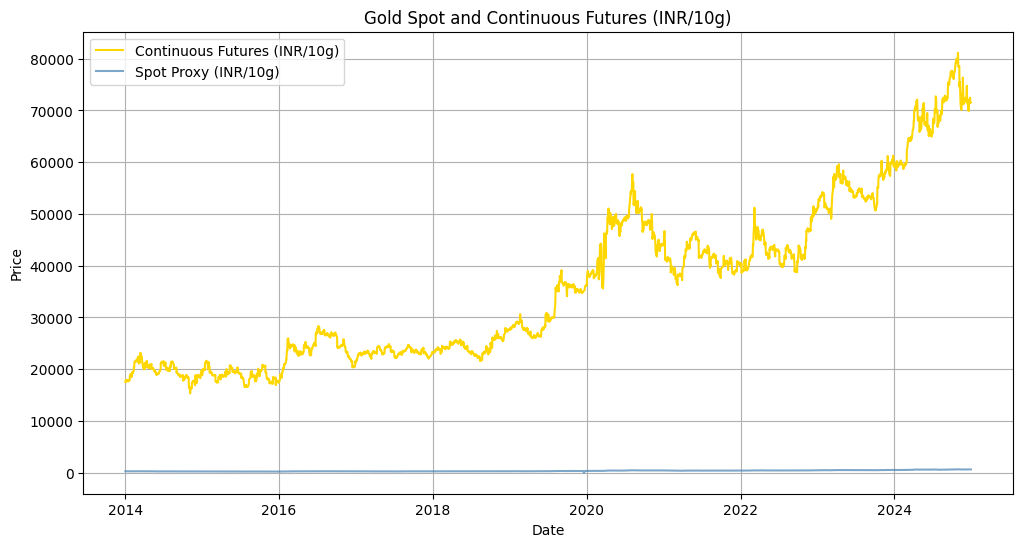

In [9]:


# Plot continuous futures used in analysis
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['futures'], label='Continuous Futures (INR/10g)', color='gold')
plt.plot(df.index, df['spot'], label='Spot Proxy (INR/10g)', color='steelblue', alpha=0.7)
plt.title('Gold Spot and Continuous Futures (INR/10g)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
# (c) Conduct unit root tests (ADF) for both spot and futures prices

def adf_test(series, title):
    result = adfuller(series.dropna())
    print(f'ADF Test: {title}')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    if result[1] < 0.05:
        print("Conclusion: Stationary (Reject Null Hypothesis)")
    else:
        print("Conclusion: Non-Stationary (Fail to Reject Null)")
    print('-' * 30)

adf_test(df['spot'], "Spot Price Proxy (INR/10g)")
adf_test(df['futures'], "Continuous Futures (INR/10g)")

ADF Test: Spot Price Proxy (INR/10g)
ADF Statistic: 0.9367
p-value: 0.9936
Conclusion: Non-Stationary (Fail to Reject Null)
------------------------------
ADF Test: Continuous Futures (INR/10g)
ADF Statistic: -0.0052
p-value: 0.9581
Conclusion: Non-Stationary (Fail to Reject Null)
------------------------------


In [11]:
# (d) Test for cointegration between spot and futures prices

# Use the cleaned and aligned master DataFrame
combined = df[['spot', 'futures']].dropna().copy()
combined.columns = ['Spot', 'Futures']

score, p_value, _ = coint(combined['Spot'], combined['Futures'])

print(f'Cointegration Test P-Value: {p_value:.4f}')

if p_value < 0.05:
    print("Economic Interpretation: The series are COINTEGRATED.")
    print("Implication: There is a long-term equilibrium between Spot and Futures.")
    print("Any divergence (basis risk) is temporary and mean-reverting.")
else:
    print("Economic Interpretation: The series are NOT COINTEGRATED.")
    print("Implication: Spot and Futures move independently in the long run.")

Cointegration Test P-Value: 0.0047
Economic Interpretation: The series are COINTEGRATED.
Implication: There is a long-term equilibrium between Spot and Futures.
Any divergence (basis risk) is temporary and mean-reverting.
